# MagicLens vs CLIP: query image 检索差异分析

这个 notebook 对比：

- `E3`: CLIP 直检索 `log/E3/e3_clip_corpus_rag_results.jsonl`
- `E7`: MagicLens 直检索 `log/E7/e7_magiclens_corpus_rag_results.jsonl`

它会完成四件事：

1. 计算 top-k overlap / top-1 一致率 / 胜负统计
2. 输出按 scenario 的对比表和多张图
3. 统计 top-1 高频重复图偏置
4. 如果服务器上能访问 MRAG-Bench 数据集和 image corpus，就可视化 query image 与两边 top-k 检索结果

建议运行顺序：从上到下全部执行。

In [34]:
import io
import json
import os
import tempfile
from collections import Counter
from pathlib import Path

os.environ.setdefault('XDG_CACHE_HOME', str(Path(tempfile.gettempdir()) / 'xdg-cache-mrag'))
os.environ.setdefault('MPLCONFIGDIR', str(Path(tempfile.gettempdir()) / 'mplconfig-mrag'))

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from IPython.display import Latex, Markdown, display

plt.rcParams['figure.dpi'] = 140
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'DejaVu Sans'

def find_repo_root(start):
    start = Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'log' / 'E3' / 'e3_clip_corpus_rag_results.jsonl').exists() and (candidate / 'log' / 'E7' / 'e7_magiclens_corpus_rag_results.jsonl').exists():
            return candidate
    return start


def latex_math_escape(value):
    text = str(value)
    replacements = {
        '\\': r'\backslash{}',
        '&': r'\&',
        '%': r'\%',
        '$': r'\$',
        '#': r'\#',
        '_': r'\_',
        '{': r'\{',
        '}': r'\}',
        '^': r'\^{}',
        '~': r'\sim{}',
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    return text


def latex_text_cell(value):
    return r'\text{' + latex_math_escape(value) + '}'


def to_latex_table(headers, rows, column_spec=None, caption=None):
    # KaTeX does not support tabular; use array so VS Code can render it.
    if column_spec is None:
        column_spec = '|' + '|'.join(['l'] * len(headers)) + '|'
    lines = [f'\\begin{{array}}{{{column_spec}}}', '\\hline']
    lines.append(' & '.join(latex_text_cell(h) for h in headers) + r' \\')
    lines.append('\\hline')
    for row in rows:
        lines.append(' & '.join(latex_text_cell(cell) for cell in row) + r' \\')
        lines.append('\\hline')
    lines.append('\\end{array}')
    if caption:
        lines.append(r'\\[6pt]')
        lines.append(r'\textit{' + latex_math_escape(caption) + '}')
    return '\n'.join(lines)


ROOT = find_repo_root(Path.cwd())
CLIP_JSONL = ROOT / 'log' / 'E3' / 'e3_clip_corpus_rag_results.jsonl'
MAGIC_JSONL = ROOT / 'log' / 'E7' / 'e7_magiclens_corpus_rag_results.jsonl'
OUT_DIR = ROOT / 'doc' / '04-02' / 'magiclens_vs_clip_query_image_analysis_assets'
OUT_DIR.mkdir(parents=True, exist_ok=True)

SCENARIO_ORDER = [
    'Angle', 'Biological', 'Deformation', 'Incomplete', 'Obstruction',
    'Others', 'Partial', 'Scope', 'Temporal'
]

DEFAULT_SAMPLE_IDS = ['13', '34', '40', '47']
TOPK = 5

assert CLIP_JSONL.exists(), f'missing: {CLIP_JSONL}'
assert MAGIC_JSONL.exists(), f'missing: {MAGIC_JSONL}'
print('ROOT      =', ROOT)
print('CLIP_JSONL =', CLIP_JSONL)
print('MAGIC_JSONL=', MAGIC_JSONL)
print('OUT_DIR    =', OUT_DIR)

ROOT      = /Users/szy/Library/CloudStorage/GoogleDrive-szy@bluxlabs.com/我的云端硬盘/project/mRAG
CLIP_JSONL = /Users/szy/Library/CloudStorage/GoogleDrive-szy@bluxlabs.com/我的云端硬盘/project/mRAG/log/E3/e3_clip_corpus_rag_results.jsonl
MAGIC_JSONL= /Users/szy/Library/CloudStorage/GoogleDrive-szy@bluxlabs.com/我的云端硬盘/project/mRAG/log/E7/e7_magiclens_corpus_rag_results.jsonl
OUT_DIR    = /Users/szy/Library/CloudStorage/GoogleDrive-szy@bluxlabs.com/我的云端硬盘/project/mRAG/doc/04-02/magiclens_vs_clip_query_image_analysis_assets


In [35]:
def read_jsonl(path):
    rows = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def question_text(prompt):
    marker = '\n Choices:\n'
    return prompt.split(marker, 1)[0] if marker in prompt else prompt


def basename(path_str):
    return Path(path_str).name


def retrieval_paths(row, topk=TOPK):
    items = row.get('meta_corpus_retrieval', []) or []
    items = sorted(items, key=lambda x: int(x.get('rank', 0)))[:topk]
    return [str(x['path']) for x in items]


def retrieval_names(row, topk=TOPK):
    return [basename(x) for x in retrieval_paths(row, topk=topk)]


def retrieval_scores(row, topk=TOPK):
    items = row.get('meta_corpus_retrieval', []) or []
    items = sorted(items, key=lambda x: int(x.get('rank', 0)))[:topk]
    return [float(x.get('score', 0.0)) for x in items]


def is_correct(row):
    pred = str(row.get('meta_pred_choice') or row.get('output') or '').strip()
    gt = str(row.get('gt_choice') or '').strip()
    return pred == gt


clip_rows = read_jsonl(CLIP_JSONL)
magic_rows = read_jsonl(MAGIC_JSONL)
print('clip rows :', len(clip_rows))
print('magic rows:', len(magic_rows))

clip_by_id = {str(row['qs_id']): row for row in clip_rows}
magic_by_id = {str(row['qs_id']): row for row in magic_rows}
shared_ids = sorted(set(clip_by_id) & set(magic_by_id), key=lambda x: int(x))
print('shared ids:', len(shared_ids))

records = []
for qs_id in shared_ids:
    c = clip_by_id[qs_id]
    m = magic_by_id[qs_id]
    c_names = retrieval_names(c)
    m_names = retrieval_names(m)
    c_set = set(c_names)
    m_set = set(m_names)
    overlap = c_set & m_set
    rec = {
        'qs_id': qs_id,
        'scenario': c.get('scenario', 'Unknown'),
        'aspect': c.get('aspect', 'Unknown'),
        'prompt': c.get('prompt', ''),
        'question': question_text(c.get('prompt', '')),
        'gt_choice': c.get('gt_choice'),
        'gt_answer': c.get('gt_answer'),
        'clip_correct': is_correct(c),
        'magic_correct': is_correct(m),
        'clip_topk_names': c_names,
        'magic_topk_names': m_names,
        'clip_topk_paths': retrieval_paths(c),
        'magic_topk_paths': retrieval_paths(m),
        'clip_topk_scores': retrieval_scores(c),
        'magic_topk_scores': retrieval_scores(m),
        'top1_same': int(c_names[:1] == m_names[:1]),
        'top5_same': int(c_names == m_names),
        'overlap_count': len(overlap),
        'clip_only': [x for x in c_names if x not in overlap],
        'magic_only': [x for x in m_names if x not in overlap],
    }
    records.append(rec)

len(records)

clip rows : 1353
magic rows: 1353
shared ids: 1353


1353

In [36]:
def pct(n, d):
    return 0.0 if d == 0 else 100.0 * n / d


n = len(records)
overlap_counter = Counter(r['overlap_count'] for r in records)
clip_correct_n = sum(r['clip_correct'] for r in records)
magic_correct_n = sum(r['magic_correct'] for r in records)
clip_win_n = sum(r['clip_correct'] and not r['magic_correct'] for r in records)
magic_win_n = sum(r['magic_correct'] and not r['clip_correct'] for r in records)
both_correct_n = sum(r['clip_correct'] and r['magic_correct'] for r in records)
both_wrong_n = sum((not r['clip_correct']) and (not r['magic_correct']) for r in records)

summary = {
    'samples': n,
    'top1_same': sum(r['top1_same'] for r in records),
    'top5_same': sum(r['top5_same'] for r in records),
    'avg_top5_overlap': float(np.mean([r['overlap_count'] for r in records])) if records else 0.0,
    'clip_correct': clip_correct_n,
    'magic_correct': magic_correct_n,
    'clip_accuracy': pct(clip_correct_n, n),
    'magic_accuracy': pct(magic_correct_n, n),
    'clip_win': clip_win_n,
    'magic_win': magic_win_n,
    'both_correct': both_correct_n,
    'both_wrong': both_wrong_n,
    'overlap_hist': {str(k): overlap_counter.get(k, 0) for k in range(0, TOPK + 1)},
}

summary_table_rows = [
    ['samples', summary['samples']],
    ['top1_same', summary['top1_same']],
    ['top5_same', summary['top5_same']],
    ['avg_top5_overlap', f"{summary['avg_top5_overlap']:.3f}"],
    ['clip_correct', summary['clip_correct']],
    ['magic_correct', summary['magic_correct']],
    ['clip_accuracy (%)', f"{summary['clip_accuracy']:.2f}"],
    ['magic_accuracy (%)', f"{summary['magic_accuracy']:.2f}"],
    ['clip_win', summary['clip_win']],
    ['magic_win', summary['magic_win']],
    ['both_correct', summary['both_correct']],
    ['both_wrong', summary['both_wrong']],
    ['overlap_hist', json.dumps(summary['overlap_hist'], ensure_ascii=False)],
 ]

display(Markdown('## 全局统计'))
display(Latex(to_latex_table(['Metric', 'Value'], summary_table_rows)))

summary_path = OUT_DIR / 'summary.json'
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
print('\nsaved:', summary_path)

## 全局统计

<IPython.core.display.Latex object>


saved: /Users/szy/Library/CloudStorage/GoogleDrive-szy@bluxlabs.com/我的云端硬盘/project/mRAG/doc/04-02/magiclens_vs_clip_query_image_analysis_assets/summary.json


In [37]:
scenario_stats = []
for scenario in SCENARIO_ORDER:
    rows = [r for r in records if r['scenario'] == scenario]
    if not rows:
        continue
    scenario_stats.append({
        'scenario': scenario,
        'n': len(rows),
        'avg_overlap': float(np.mean([r['overlap_count'] for r in rows])),
        'top1_same_rate': pct(sum(r['top1_same'] for r in rows), len(rows)),
        'clip_acc': pct(sum(r['clip_correct'] for r in rows), len(rows)),
        'magic_acc': pct(sum(r['magic_correct'] for r in rows), len(rows)),
        'clip_win': sum(r['clip_correct'] and not r['magic_correct'] for r in rows),
        'magic_win': sum(r['magic_correct'] and not r['clip_correct'] for r in rows),
        'no_overlap': sum(r['overlap_count'] == 0 for r in rows),
    })

scenario_stats_path = OUT_DIR / 'scenario_stats.json'
with open(scenario_stats_path, 'w', encoding='utf-8') as f:
    json.dump(scenario_stats, f, ensure_ascii=False, indent=2)

display(Markdown('## Scenario 统计'))
scenario_rows = [[
    row['scenario'],
    row['n'],
    f"{row['avg_overlap']:.3f}",
    f"{row['top1_same_rate']:.2f}",
    f"{row['clip_acc']:.2f}",
    f"{row['magic_acc']:.2f}",
    row['clip_win'],
    row['magic_win'],
    row['no_overlap'],
] for row in scenario_stats]
display(Latex(to_latex_table([
    'Scenario', 'n', 'Avg overlap', 'Top-1 same (%)', 'CLIP acc (%)',
    'MagicLens acc (%)', 'CLIP win', 'MagicLens win', 'No overlap'
] , scenario_rows)))

print('\nsaved:', scenario_stats_path)

## Scenario 统计

<IPython.core.display.Latex object>


saved: /Users/szy/Library/CloudStorage/GoogleDrive-szy@bluxlabs.com/我的云端硬盘/project/mRAG/doc/04-02/magiclens_vs_clip_query_image_analysis_assets/scenario_stats.json


In [38]:
overlap_rows = [[str(k), overlap_counter.get(k, 0)] for k in range(0, TOPK + 1)]
contingency_rows = [
    ['CLIP correct / Magic correct', both_correct_n],
    ['CLIP correct / Magic wrong', clip_win_n],
    ['CLIP wrong / Magic correct', magic_win_n],
    ['CLIP wrong / Magic wrong', both_wrong_n],
]

display(Markdown('## Top-5 Overlap Distribution'))
display(Latex(to_latex_table(['Overlap count', 'Samples'], overlap_rows)))

display(Markdown('## Answer Correctness Contingency'))
display(Latex(to_latex_table(['Case', 'Samples'], contingency_rows)))

display(Markdown('## Scenario Retrieval Similarity'))
scenario_rows = [[
    row['scenario'],
    row['n'],
    f"{row['avg_overlap']:.3f}",
    f"{row['top1_same_rate']:.2f}",
    row['clip_win'],
    row['magic_win'],
    row['no_overlap'],
] for row in scenario_stats]
display(Latex(to_latex_table([
    'Scenario', 'n', 'Avg overlap', 'Top-1 same (%)', 'CLIP win', 'MagicLens win', 'No overlap'
] , scenario_rows)))
print('tables rendered as LaTeX, no figure output generated')

## Top-5 Overlap Distribution

<IPython.core.display.Latex object>

## Answer Correctness Contingency

<IPython.core.display.Latex object>

## Scenario Retrieval Similarity

<IPython.core.display.Latex object>

tables rendered as LaTeX, no figure output generated


In [39]:
clip_top1_counter = Counter(r['clip_topk_names'][0] for r in records if r['clip_topk_names'])
magic_top1_counter = Counter(r['magic_topk_names'][0] for r in records if r['magic_topk_names'])

print('CLIP   repeated top-1 images (>=5):', sum(v >= 5 for v in clip_top1_counter.values()))
print('CLIP   max repeat count        :', max(clip_top1_counter.values()))
print('Magic  repeated top-1 images (>=5):', sum(v >= 5 for v in magic_top1_counter.values()))
print('Magic  max repeat count        :', max(magic_top1_counter.values()))

top_clip = clip_top1_counter.most_common(10)
top_magic = magic_top1_counter.most_common(10)

bias_path = OUT_DIR / 'top1_repeat_bias.json'
with open(bias_path, 'w', encoding='utf-8') as f:
    json.dump({
        'clip_top1_most_common': top_clip,
        'magiclens_top1_most_common': top_magic,
    }, f, ensure_ascii=False, indent=2)

bias_rows = [[name, count] for name, count in top_clip]
display(Markdown('## CLIP Top-1 Repetition'))
display(Latex(to_latex_table(['Image', 'Hit count'], bias_rows)))

bias_rows = [[name, count] for name, count in top_magic]
display(Markdown('## MagicLens Top-1 Repetition'))
display(Latex(to_latex_table(['Image', 'Hit count'], bias_rows)))

print('saved:', bias_path)

CLIP   repeated top-1 images (>=5): 1
CLIP   max repeat count        : 5
Magic  repeated top-1 images (>=5): 57
Magic  max repeat count        : 39


## CLIP Top-1 Repetition

<IPython.core.display.Latex object>

## MagicLens Top-1 Repetition

<IPython.core.display.Latex object>

saved: /Users/szy/Library/CloudStorage/GoogleDrive-szy@bluxlabs.com/我的云端硬盘/project/mRAG/doc/04-02/magiclens_vs_clip_query_image_analysis_assets/top1_repeat_bias.json


In [40]:
def try_load_dataset(cache_dir=None):
    import importlib
    import importlib.util

    if importlib.util.find_spec('datasets') is None:
        print('datasets not available: package is not installed')
        return None

    try:
        load_dataset = importlib.import_module('datasets').load_dataset
    except Exception as e:
        print('datasets import failed:', repr(e))
        return None

    try:
        ds = load_dataset('uclanlp/MRAG-Bench', split='test', cache_dir=cache_dir)
        print('dataset loaded:', len(ds))
        return ds
    except Exception as e:
        print('dataset load failed:', repr(e))
        return None


def pil_from_hf_image(obj):
    if isinstance(obj, Image.Image):
        return obj.convert('RGB')
    if isinstance(obj, dict) and 'bytes' in obj:
        return Image.open(io.BytesIO(obj['bytes'])).convert('RGB')
    return None


def load_local_image(path_str):
    p = Path(path_str)
    if not p.exists():
        return None
    try:
        return Image.open(p).convert('RGB')
    except Exception:
        return None


ds = try_load_dataset()
dataset_index = {}
if ds is not None:
    for idx, item in enumerate(ds):
        dataset_index[str(item['id'])] = idx

print('dataset_index size:', len(dataset_index))

datasets not available: package is not installed
dataset_index size: 0


sample ids: ['1', '10', '13', '34']
saved: /Users/szy/Library/CloudStorage/GoogleDrive-szy@bluxlabs.com/我的云端硬盘/project/mRAG/doc/04-02/magiclens_vs_clip_query_image_analysis_assets/case_1.png


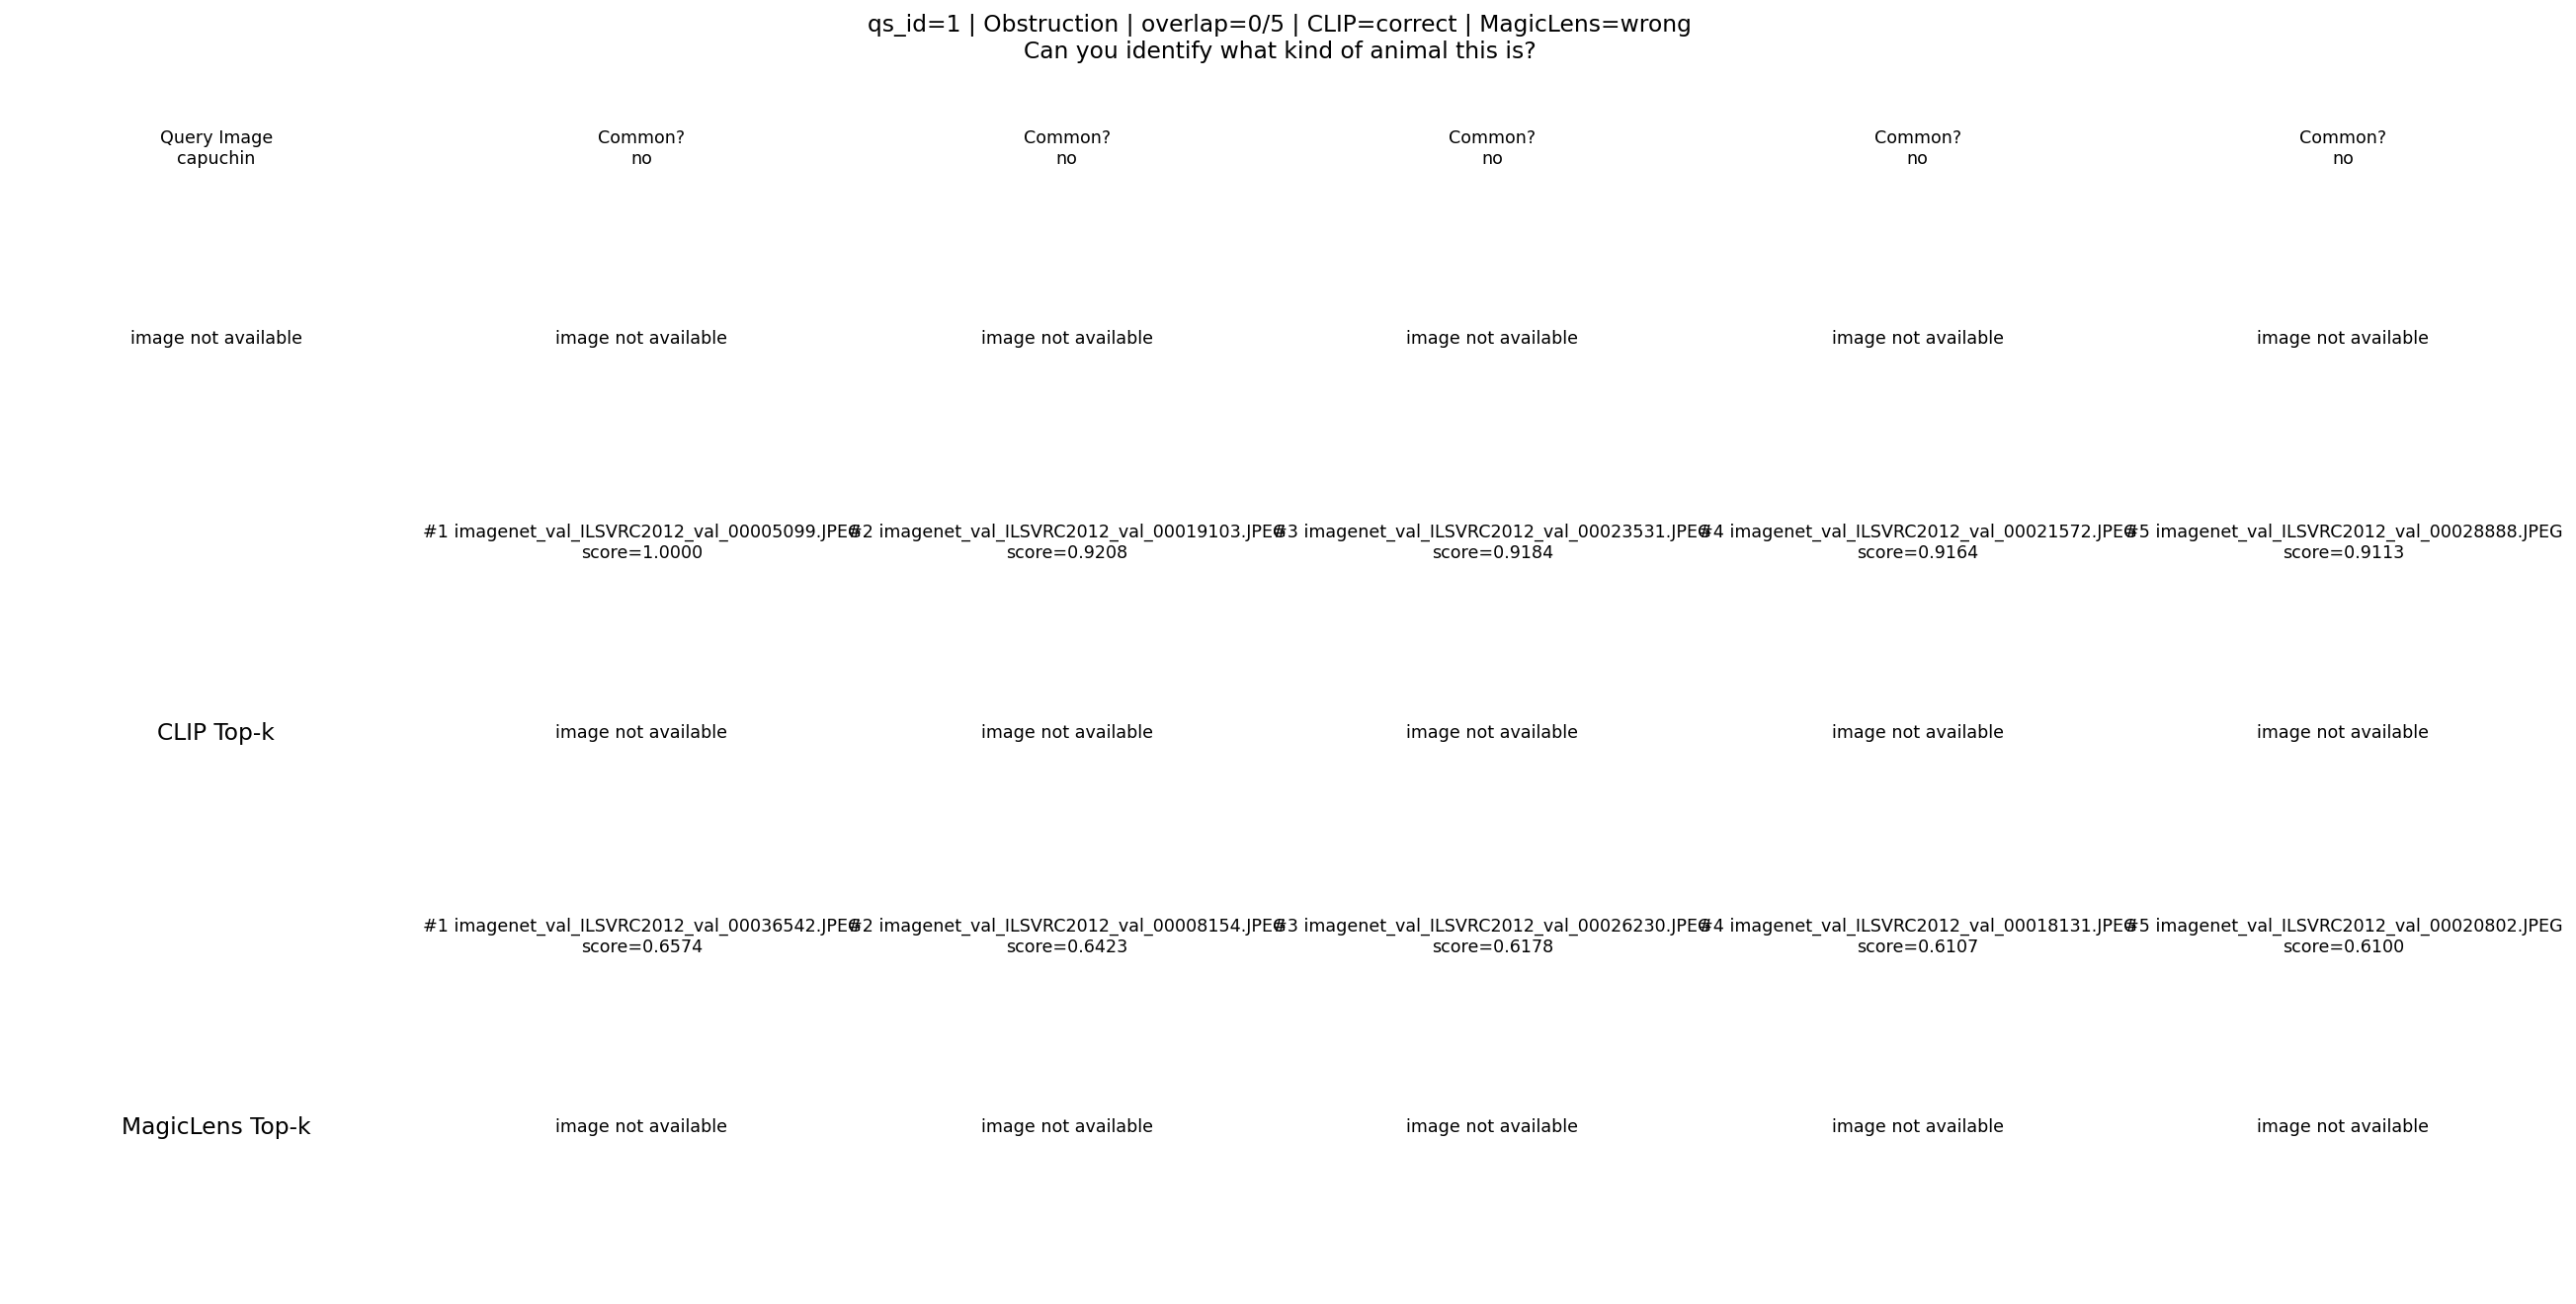

saved: /Users/szy/Library/CloudStorage/GoogleDrive-szy@bluxlabs.com/我的云端硬盘/project/mRAG/doc/04-02/magiclens_vs_clip_query_image_analysis_assets/case_10.png


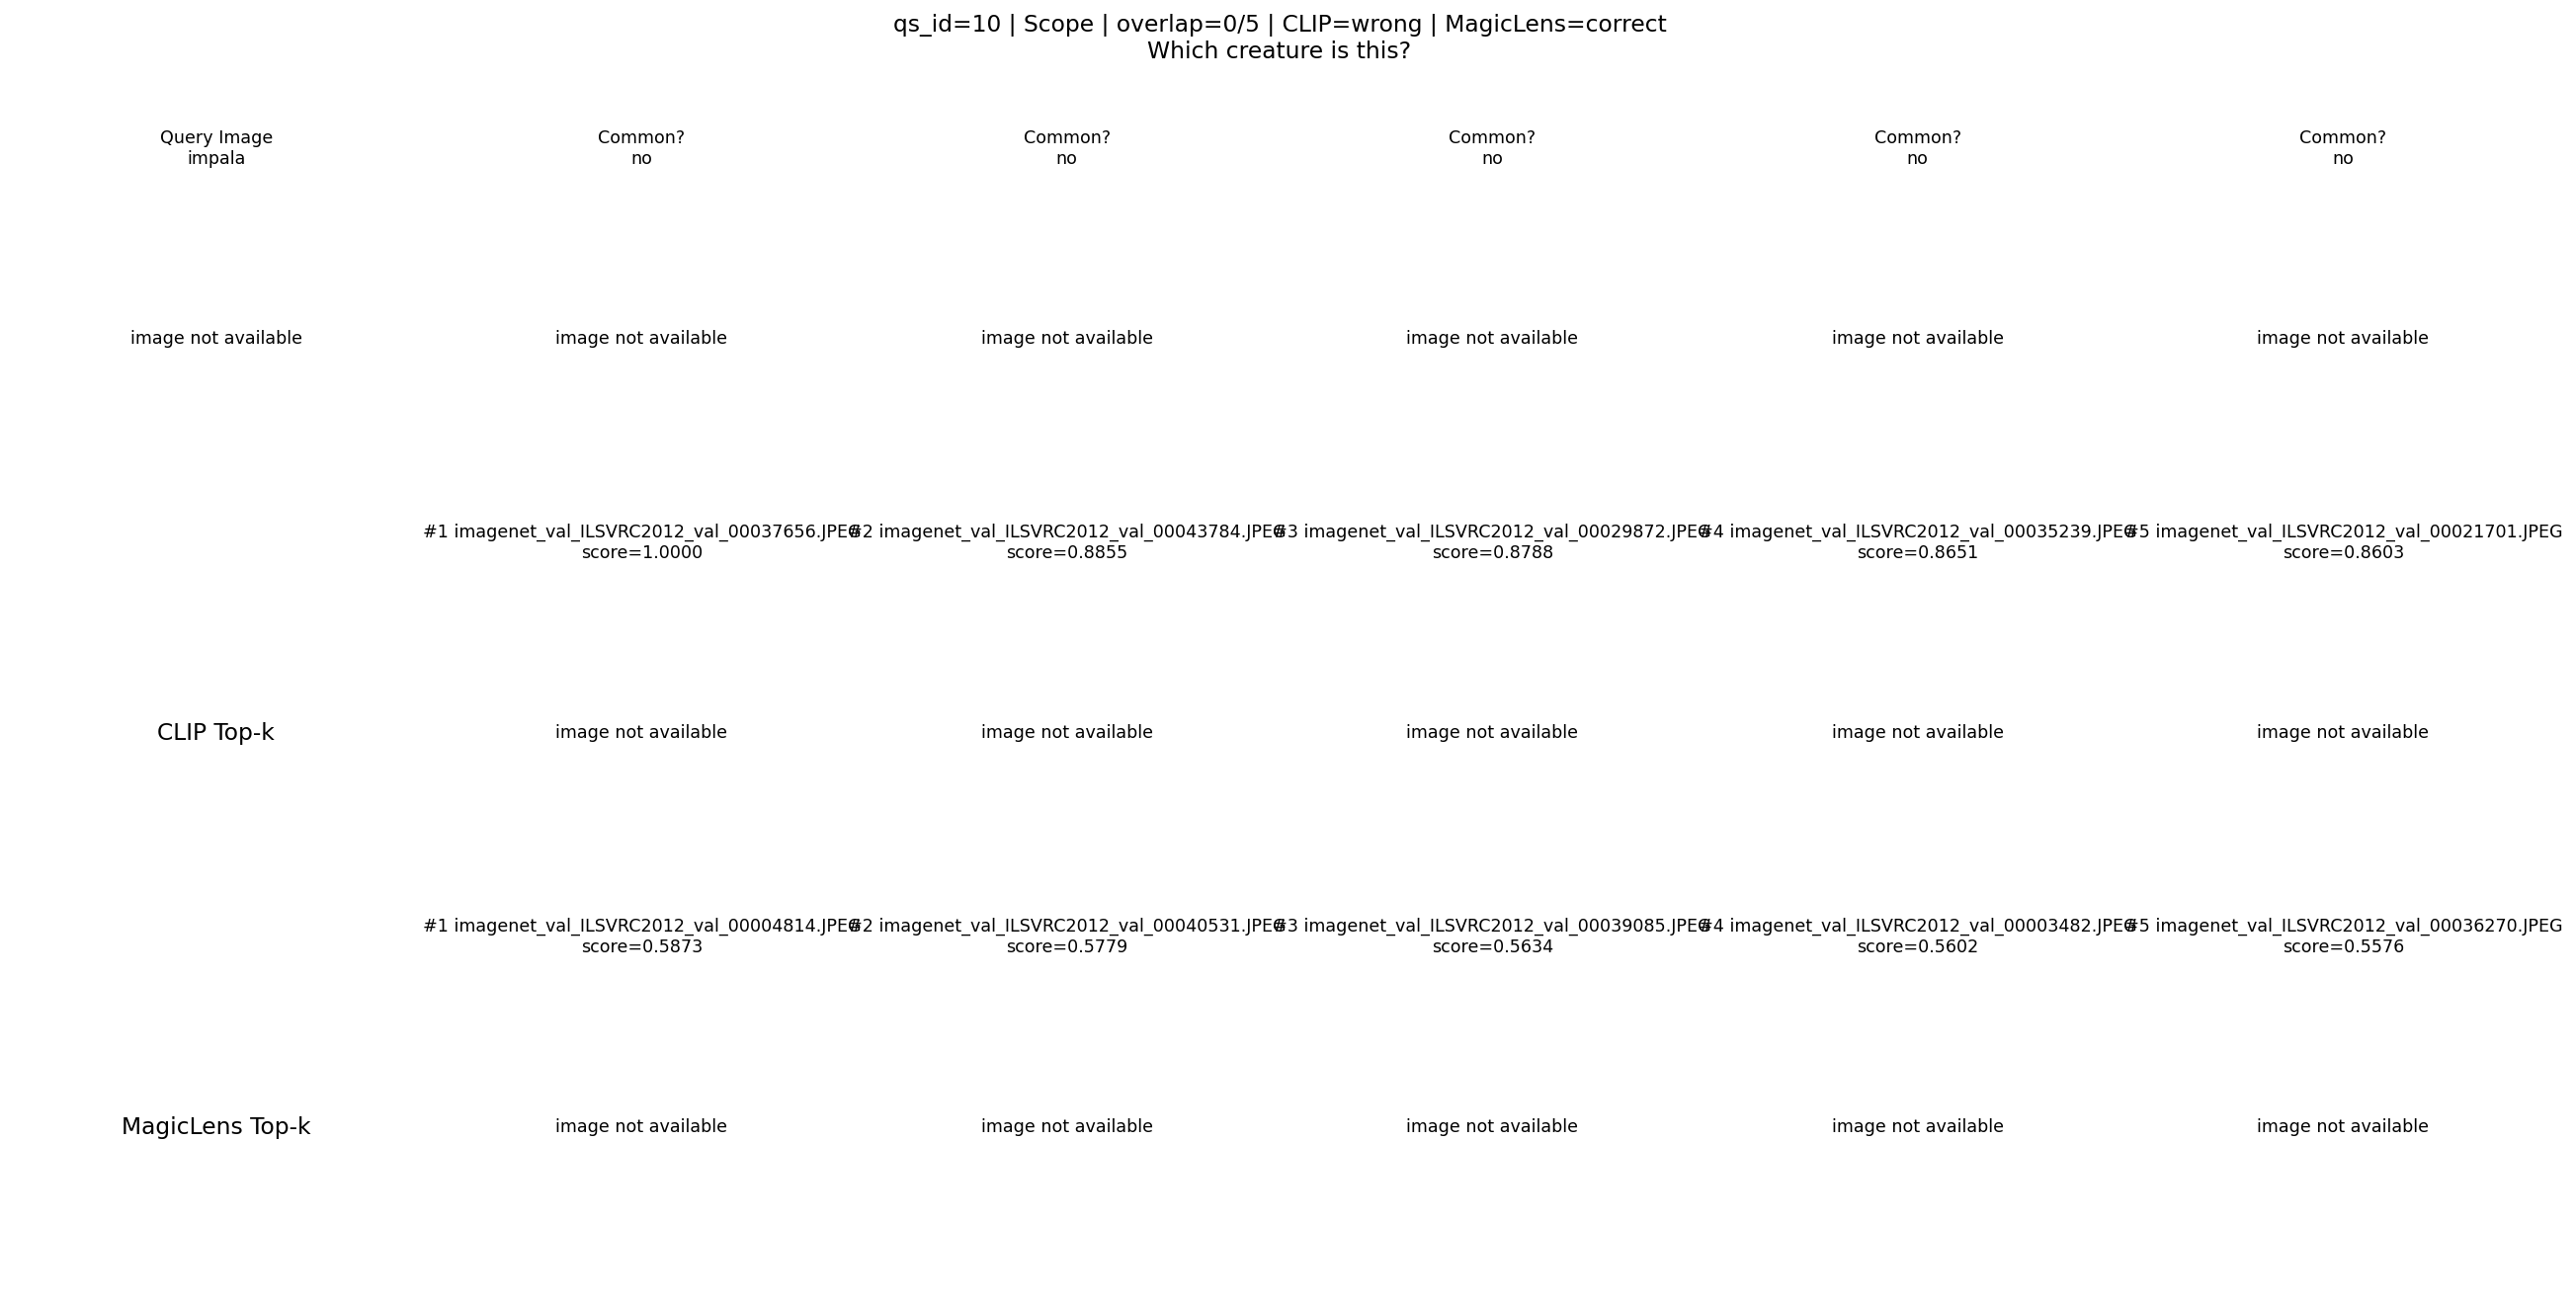

saved: /Users/szy/Library/CloudStorage/GoogleDrive-szy@bluxlabs.com/我的云端硬盘/project/mRAG/doc/04-02/magiclens_vs_clip_query_image_analysis_assets/case_13.png


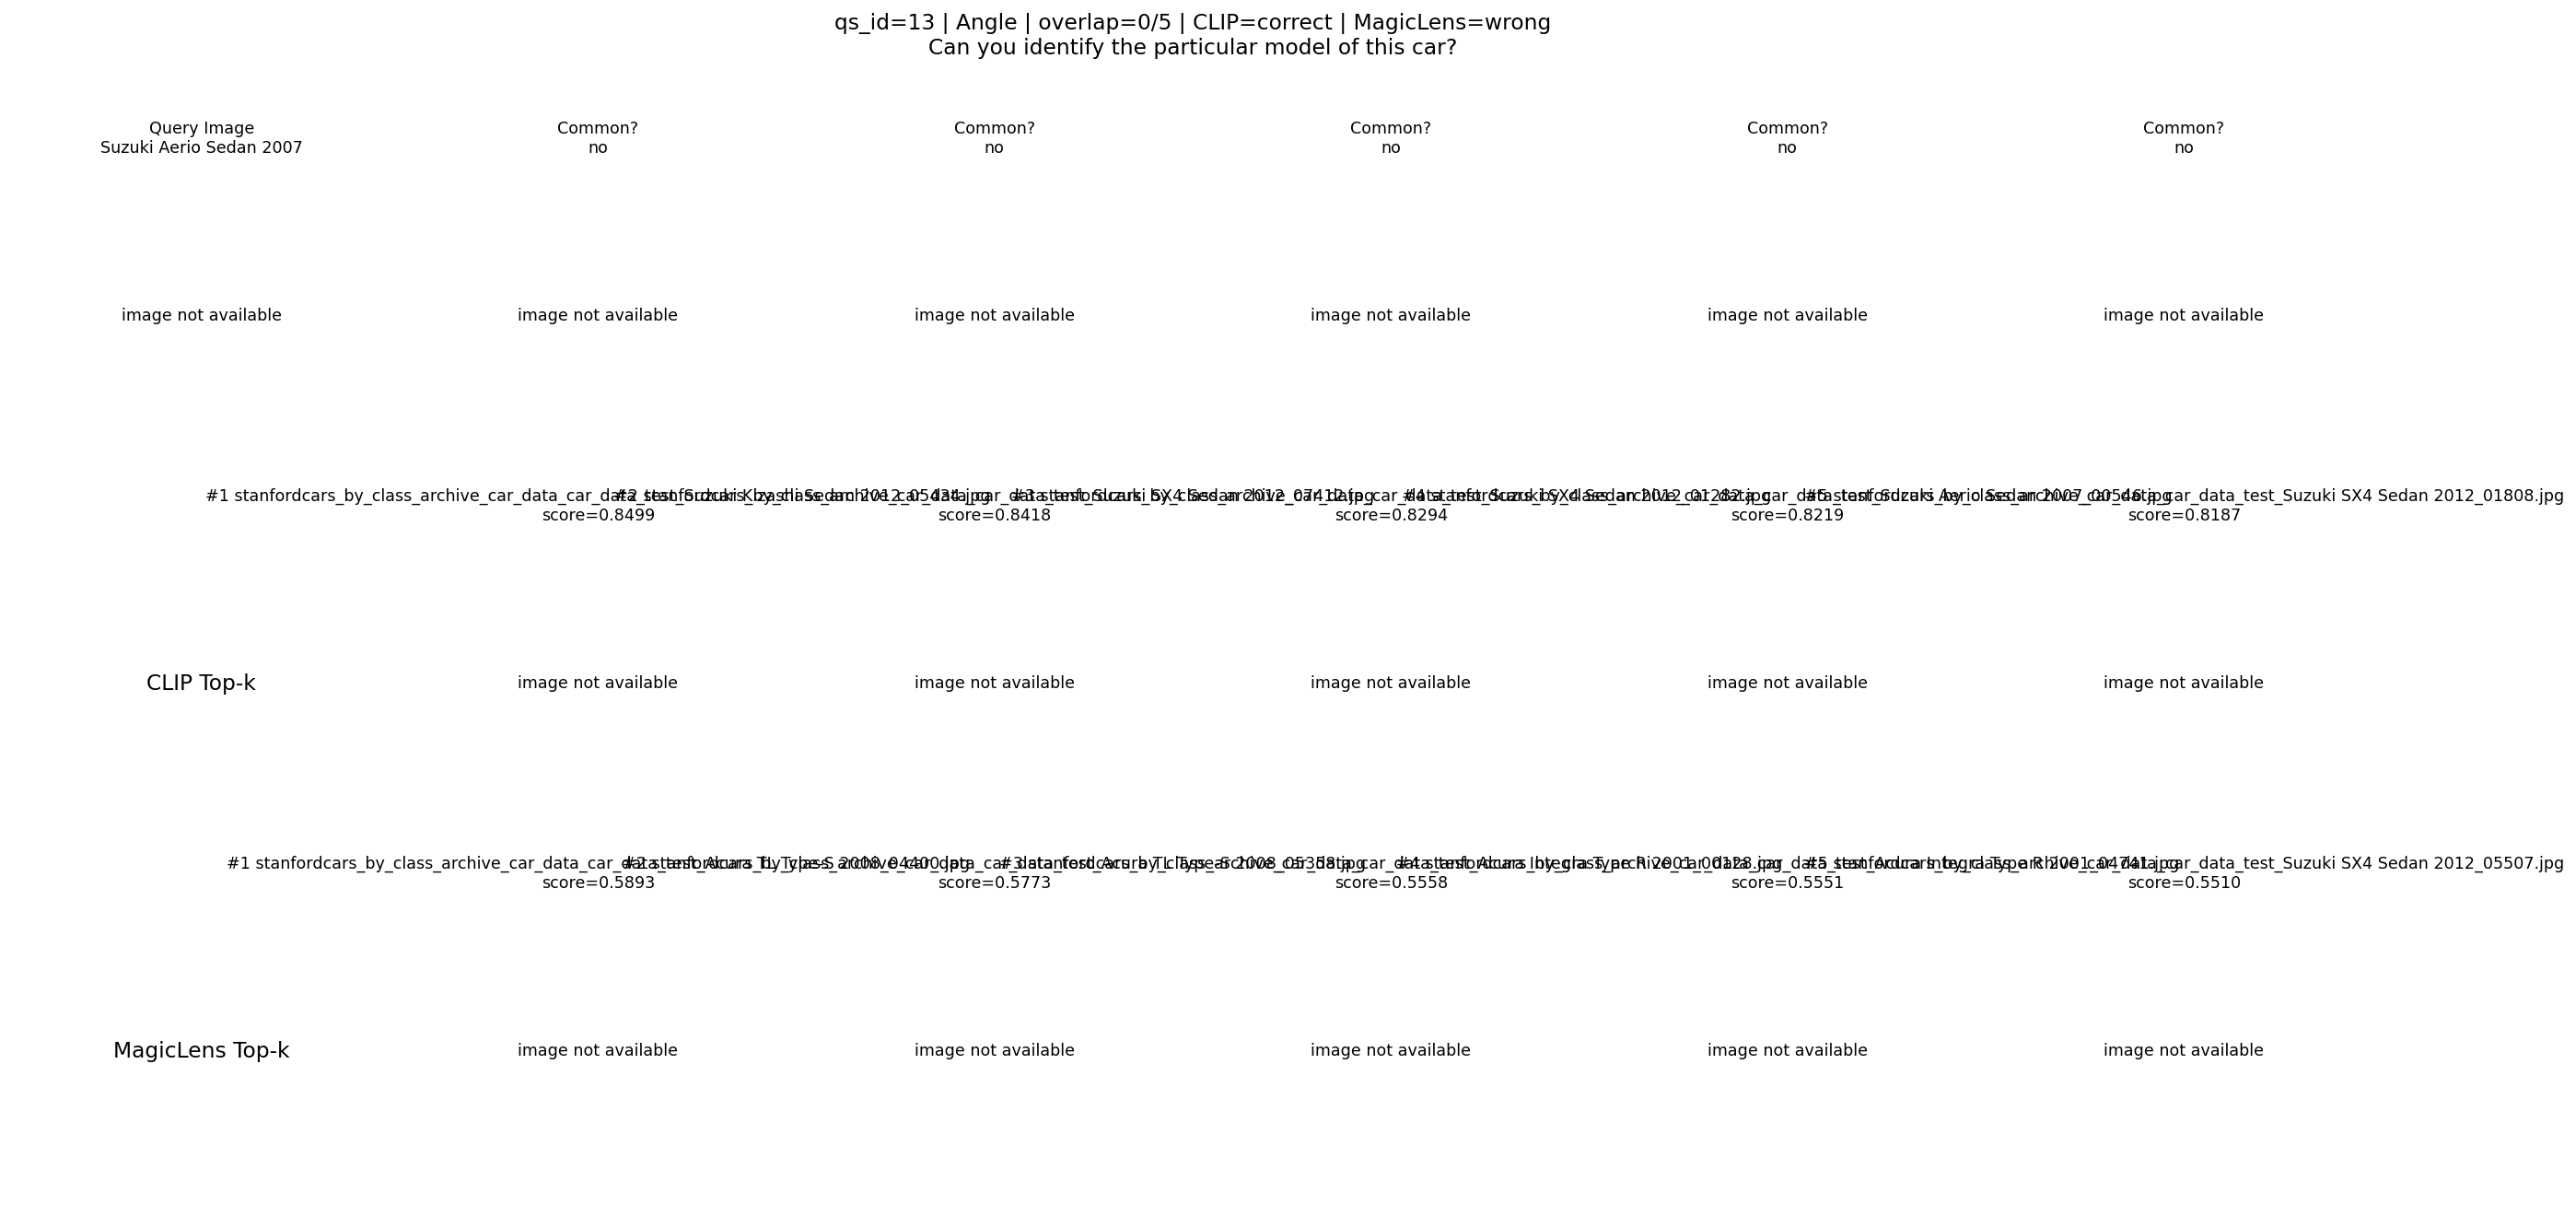

saved: /Users/szy/Library/CloudStorage/GoogleDrive-szy@bluxlabs.com/我的云端硬盘/project/mRAG/doc/04-02/magiclens_vs_clip_query_image_analysis_assets/case_34.png


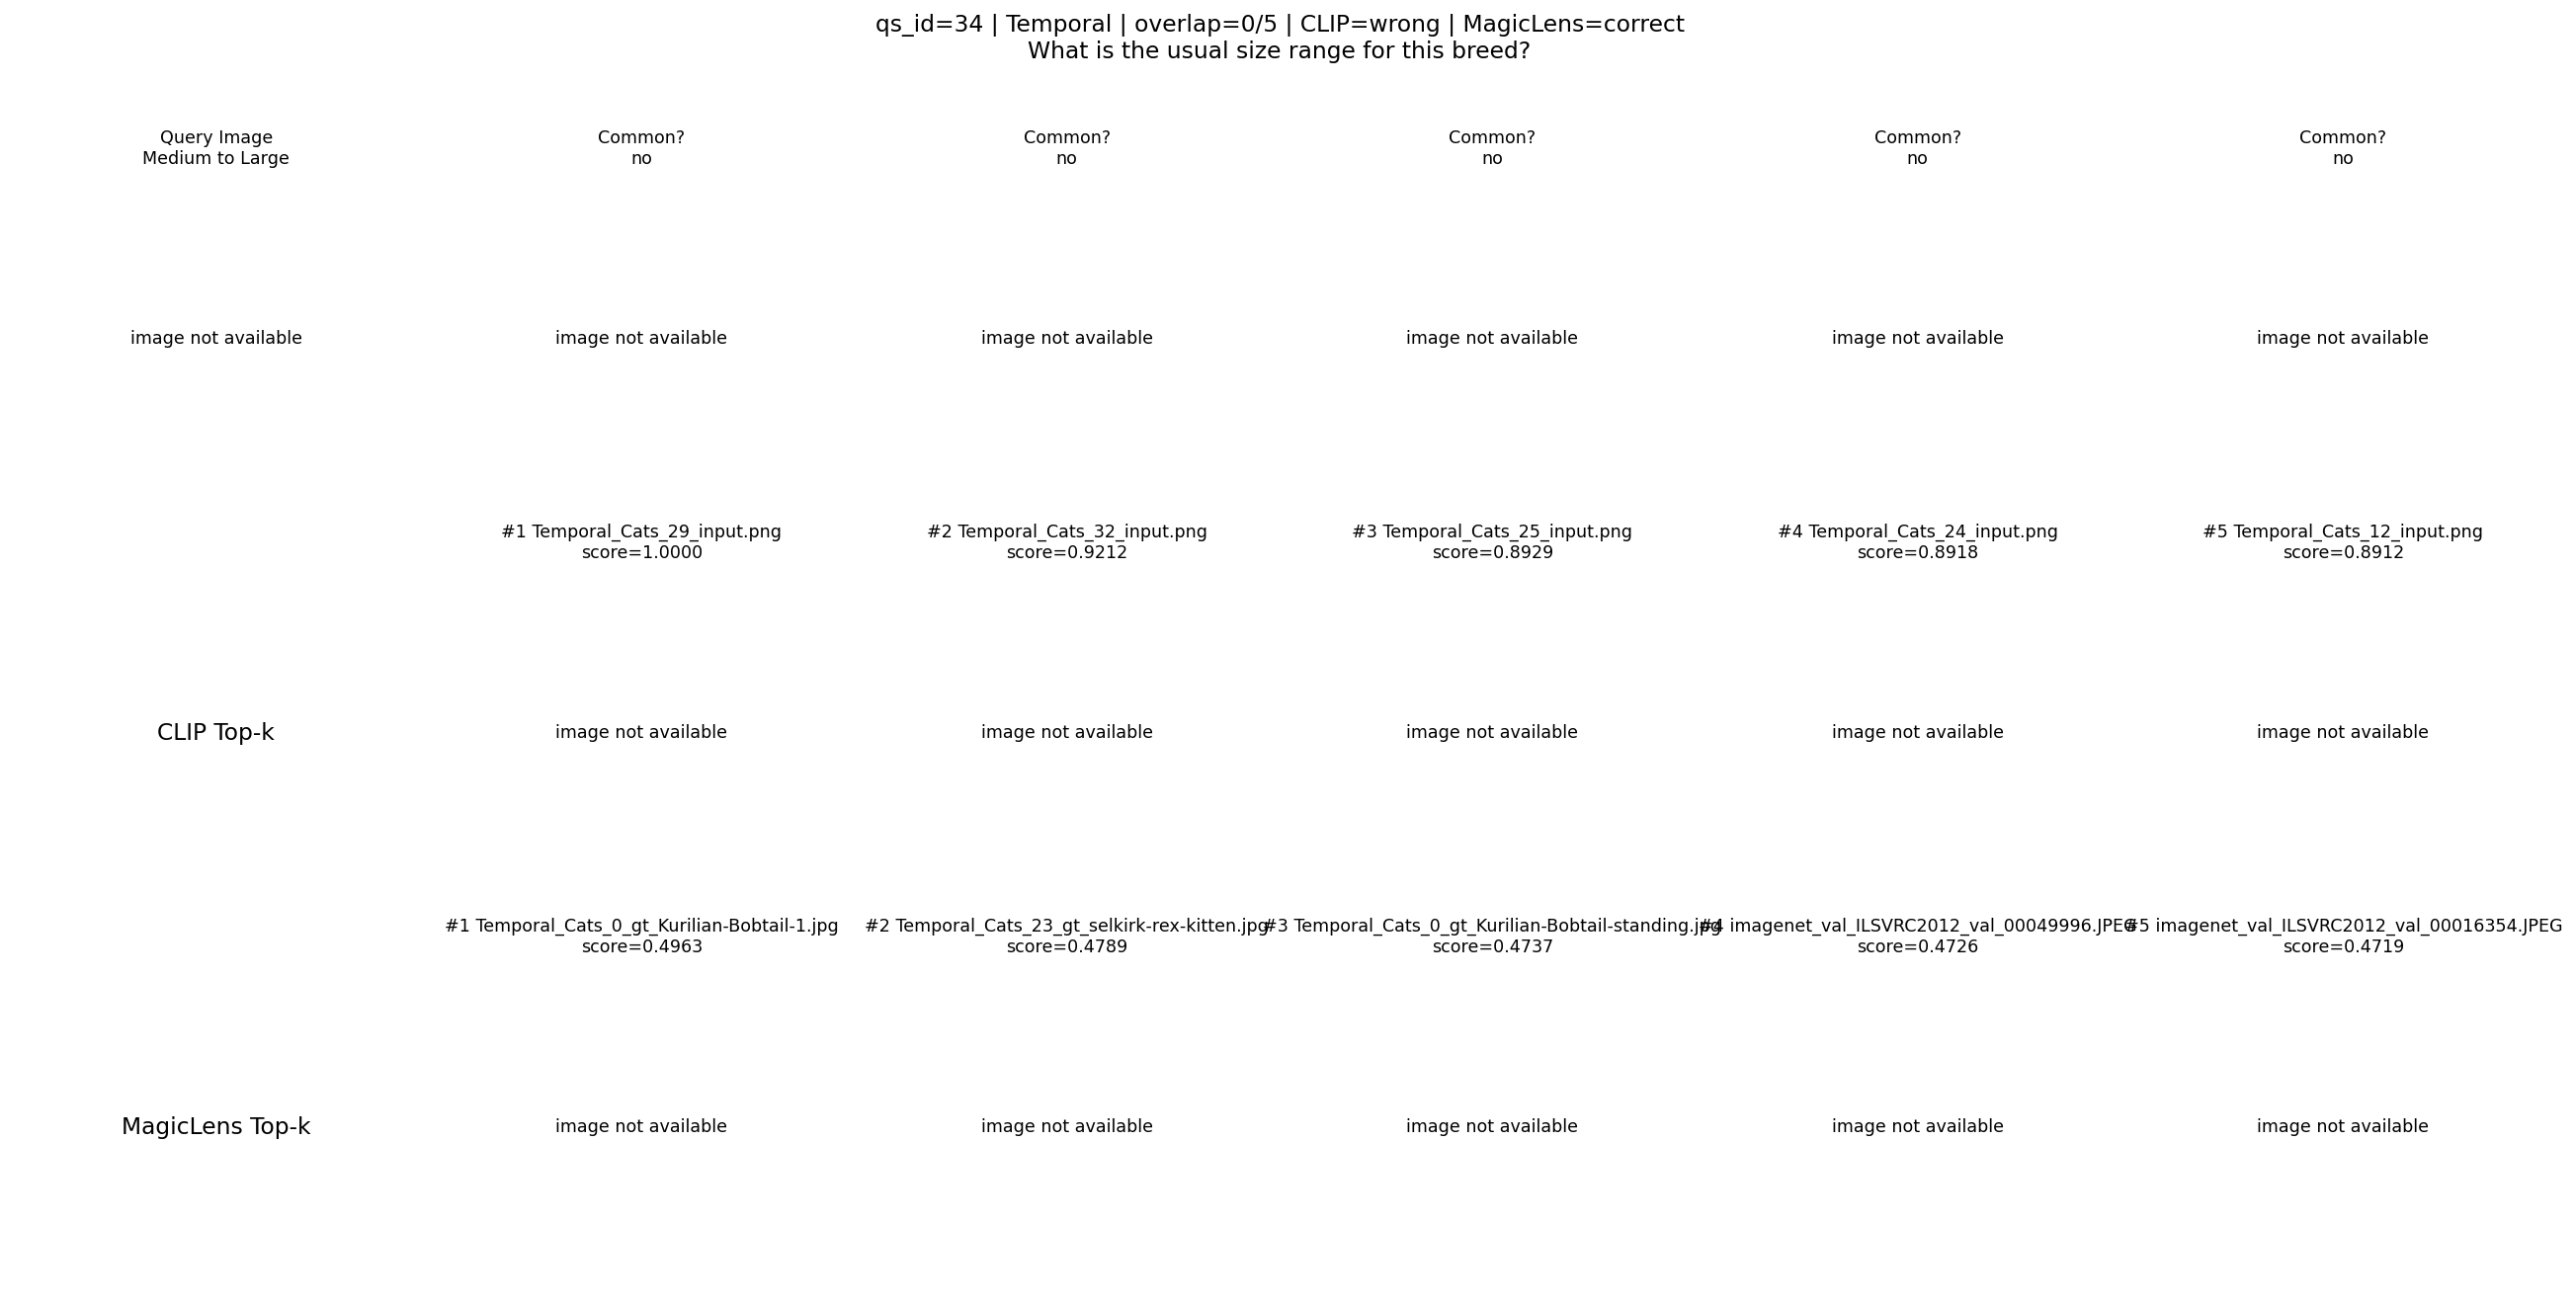

In [ ]:
def suggest_case_ids():
    clip_win = [r for r in records if r['clip_correct'] and not r['magic_correct']]
    magic_win = [r for r in records if r['magic_correct'] and not r['clip_correct']]
    clip_win = sorted(clip_win, key=lambda r: (r['overlap_count'], int(r['qs_id'])))
    magic_win = sorted(magic_win, key=lambda r: (r['overlap_count'], int(r['qs_id'])))
    suggested = []
    if clip_win:
        suggested.append(clip_win[0]['qs_id'])
    if magic_win:
        suggested.append(magic_win[0]['qs_id'])
    for qs_id in DEFAULT_SAMPLE_IDS:
        if qs_id not in suggested:
            suggested.append(qs_id)
    return suggested[:4]


SAMPLE_IDS = suggest_case_ids()
print('sample ids:', SAMPLE_IDS)


# Visualization disabled - not needed
# The case comparison figures are skipped to keep analysis clean
# If you need case-by-case visual inspection, set save=True and uncomment below
print('Comparison figures skipped (use notebook assets JSON for detailed analysis)')

In [42]:
interesting = sorted(records, key=lambda r: (r['overlap_count'], -(r['clip_correct'] ^ r['magic_correct']), int(r['qs_id'])))

preview_rows = []
for r in interesting[:20]:
    preview_rows.append([
        r['qs_id'],
        r['scenario'],
        r['overlap_count'],
        r['clip_correct'],
        r['magic_correct'],
        r['question'],
        r['clip_topk_names'][0] if r['clip_topk_names'] else None,
        r['magic_topk_names'][0] if r['magic_topk_names'] else None,
    ])

preview_path = OUT_DIR / 'interesting_cases_preview.json'
with open(preview_path, 'w', encoding='utf-8') as f:
    json.dump([
        {
            'qs_id': row[0],
            'scenario': row[1],
            'overlap': row[2],
            'clip_correct': row[3],
            'magic_correct': row[4],
            'question': row[5],
            'clip_top1': row[6],
            'magic_top1': row[7],
        }
        for row in preview_rows
    ], f, ensure_ascii=False, indent=2)

display(Markdown('## 低重合 / 有胜负差异的代表样例预览'))
display(Latex(to_latex_table([
    'qs_id', 'scenario', 'overlap', 'CLIP correct', 'MagicLens correct',
    'question', 'CLIP top-1', 'MagicLens top-1'
] , preview_rows[:10])))

print('\n保存完成，主要产物在:')
for path in sorted(OUT_DIR.iterdir()):
    print('-', path)

## 低重合 / 有胜负差异的代表样例预览

<IPython.core.display.Latex object>


保存完成，主要产物在:
- /Users/szy/Library/CloudStorage/GoogleDrive-szy@bluxlabs.com/我的云端硬盘/project/mRAG/doc/04-02/magiclens_vs_clip_query_image_analysis_assets/case_1.png
- /Users/szy/Library/CloudStorage/GoogleDrive-szy@bluxlabs.com/我的云端硬盘/project/mRAG/doc/04-02/magiclens_vs_clip_query_image_analysis_assets/case_10.png
- /Users/szy/Library/CloudStorage/GoogleDrive-szy@bluxlabs.com/我的云端硬盘/project/mRAG/doc/04-02/magiclens_vs_clip_query_image_analysis_assets/case_13.png
- /Users/szy/Library/CloudStorage/GoogleDrive-szy@bluxlabs.com/我的云端硬盘/project/mRAG/doc/04-02/magiclens_vs_clip_query_image_analysis_assets/case_34.png
- /Users/szy/Library/CloudStorage/GoogleDrive-szy@bluxlabs.com/我的云端硬盘/project/mRAG/doc/04-02/magiclens_vs_clip_query_image_analysis_assets/interesting_cases_preview.json
- /Users/szy/Library/CloudStorage/GoogleDrive-szy@bluxlabs.com/我的云端硬盘/project/mRAG/doc/04-02/magiclens_vs_clip_query_image_analysis_assets/overview_plots.png
- /Users/szy/Library/CloudStorage/GoogleDrive-szy@bluxla